# Quantum phase transitions — mapping a phase diagram from finite chains

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 13 — Quantum phase transitions*

## 1. Introduction and motivation

A **quantum phase transition** happens at zero temperature. There is no thermal noise to disorder anything; what
competes are non-commuting terms of the Hamiltonian, and the control parameter is a coupling. Tune it, and at some
critical value the ground state reorganises qualitatively: an order parameter switches on, the gap to the first
excited state closes, correlations become long-ranged.

That is the textbook statement, and it holds **only in the thermodynamic limit**. On the finite chains a computer
can hold, none of it is literally true:

* the ground-state energy is an analytic function of the coupling — a finite matrix has no singularities;
* the gap never closes, it only becomes small;
* no symmetry is ever broken, so the order parameter $\langle Z_j\rangle$ is exactly zero on *both* sides.

So the practical problem of this notebook is not "compute the transition" but **extract a sharp statement about
the infinite system from smooth data on small ones**. That is a numerical-methods question, and the answer -
finite-size scaling - is the same one used for classical Monte Carlo, for cold-atom experiments with a few hundred
atoms, and for the tensor-network calculations of the previous chapters.

We use the **transverse-field Ising model** (TFIM) as the benchmark,

$$ H = -J\sum_{i=0}^{N-2} Z_iZ_{i+1} - h\sum_{i=0}^{N-1}X_i , \qquad (1) $$

because it is exactly solvable: we know the answer for the critical point, the exponents and the central charge,
and can therefore *grade* every numerical signature instead of merely admiring it. Only then do we point the same
tools at a model where they are harder to use.

**Road map.**

1. The model, its symmetry, and the exact results we will use as a grader (Sec. 2).
2. The tool: Lanczos restricted to a symmetry sector, which gives the ground state *and* the first excited state
   from two ground-state calculations (Sec. 3).
3. Four independent signatures of the transition, each computed and each compared with the exact answer:
   the order parameter (Sec. 4), the gap and the crossing of $N\Delta$ (Sec. 5), the entanglement entropy and the
   central charge (Sec. 6),
   and the fidelity susceptibility, which needs no order parameter at all (Sec. 7).
4. Finite-size scaling: pseudo-critical points, extrapolation to $N\to\infty$, and data collapse with the
   exponents $\nu$, $\beta$, $z$ (Sec. 8).
5. A second universality class for free: the XX chain at $N=200$ from its correlation matrix, with $c=1$ (Sec. 9).
6. A transition that finite-size scaling handles badly: the Kosterlitz-Thouless point of the XXZ chain (Sec. 10).
7. Cost, limits, takeaways, exercises (Secs. 11-13).

### What you will learn

* Why $\langle Z_j\rangle=0$ on every finite chain, and what to measure instead.
* How to get an excited state from a ground-state solver by using a symmetry.
* Four ways to see one transition, and what each costs.
* How to turn $N=8,\dots,16$ into a critical point and two exponents, and how far to trust the result.
* Why a Kosterlitz-Thouless transition defeats the same procedure, and how to recognise that from the data.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
_SPIN_MPS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}      # same characters as product_state
@jax.jit
def mps_to_state(B):
    """Padded MPS -> state tensor (validation only, O(2^N)).  The dummy boundary bonds are index 0.
    JAX: the shapes are static, so the whole chain of N contractions is compiled once per (N, chi)."""
    psi = B[0][0]                                          # (2, chi): left boundary leg fixed to 0
    for j in range(1, B.shape[0]):
        psi = jnp.tensordot(psi, B[j], axes=([-1], [0]))
    return psi[..., 0]                                     # right boundary leg fixed to 0

def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN_MPS[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)

def mps_expect_sites(B, lam, O):
    """<O_j> for ALL sites j at once.   MATH  theta_j = lam[j] B[j];  <O_j> = sum theta*[a,t,b] O[t,s] theta[a,s,b].
    COST O(N chi^2).  The letter j in the einsum is a batch index (one independent contraction per site)."""
    theta = lam[:-1, :, None, None] * B
    return jnp.real(jnp.einsum("jatb,ts,jasb->j", jnp.conj(theta), jnp.asarray(O, dtype=B.dtype), theta))

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def mps_correlator(B, lam, O, i, P, j):
    """<O_i P_j> for i < j (static ints) with a transfer-matrix sweep between the two sites.  COST O((j-i) chi^3)."""
    O, P = jnp.asarray(O, dtype=B.dtype), jnp.asarray(P, dtype=B.dtype)
    theta = lam[i][:, None, None] * B[i]
    E = jnp.einsum("atb,ts,asc->bc", jnp.conj(theta), O, theta)       # open legs: right bonds (bra b, ket c)
    for k in range(i + 1, j):
        E = jnp.einsum("bc,bsd,cse->de", E, jnp.conj(B[k]), B[k])     # push through site k
    return jnp.real(jnp.einsum("bc,btd,ts,csd->", E, jnp.conj(B[j]), P, B[j]))

def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws

def mpo_to_dense(Ws):
    """Contract an MPO into the dense 2^N x 2^N matrix (validation only, small N).
    MATH  M_(j)[w] = sum_v M_(j-1)[v] (x) W[j][v, w]   starting from row 4 of site 0; the result is column 0 after the last site."""
    N, D = Ws.shape[0], Ws.shape[1]
    M = Ws[0][4]                                                            # (w, s_out, s_in) after site 0
    for j in range(1, N):
        M = jnp.einsum("vab,vwcd->wacbd", M, Ws[j]).reshape(D, 2 ** (j + 1), 2 ** (j + 1))
    return M[0]

def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")

def lanczos_lowest(matvec, v0, m):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    JAX     fixed m (lax.scan); after a breakdown (beta ~ 0) the unused rows of T get the diagonal 1e6, so that their
            spurious zero eigenvalues are pushed to the top of the spectrum.
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def body(carry, j):
        V, v, v_prev, beta_prev, alive = carry
        w = matvec(v.reshape(shape)).reshape(-1)
        alpha = jnp.real(jnp.vdot(v, w))
        w = w - alpha * v - beta_prev * v_prev
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # w <- w - sum_i v_i <v_i|w>; V holds the v_i as ROWS, hence the two conjugations
        w = w - jnp.conj(V @ jnp.conj(w)) @ V                   # ... once more (rounding)
        beta = jnp.linalg.norm(w)
        ok = alive & (beta > 1e-12)
        v_next = jnp.where(ok, w / jnp.where(ok, beta, 1.0), 0.0)
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        alpha = jnp.where(alive, alpha, 1e6)                     # breakdown guard: a zero row of T would give a spurious eigenvalue 0
        return (V, v_next, v, jnp.where(ok, beta, 0.0), ok), (alpha, jnp.where(ok, beta, 0.0))

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True))
    (V, *_), (alphas, betas) = lax.scan(body, init, jnp.arange(m))
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)

def split_two_site(theta, chi, move_right):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    U, Vh = U[:, :chi], Vh[:chi]
    if move_right:
        return U.reshape(chi, 2, chi), (S[:, None] * Vh).reshape(chi, 2, chi), S, eps
    return (U * S[None, :]).reshape(chi, 2, chi), Vh.reshape(chi, 2, chi), S, eps

_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)
def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m)     # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right)                  # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step

def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the right-canonical padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    """
    N, D = W.shape[0], W.shape[1]
    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    return jnp.stack(M), lam, history


## 2. The model, its symmetry, and the exact answers

### 2.1 What the two terms want

In Eq. (1) the two terms disagree. The Ising coupling $-JZ_iZ_{i+1}$ with $J>0$ is minimised by the two
ferromagnetic product states $|\!\uparrow\uparrow\cdots\rangle$ and $|\!\downarrow\downarrow\cdots\rangle$; the field
$-hX_i$ is minimised by the single product state $|+\rangle^{\otimes N}$, which has no $Z$-order at all. At $h\ll J$
the ground state is (almost) ferromagnetic and **doubly degenerate** in the thermodynamic limit; at $h\gg J$ it is
(almost) $|+\rangle^{\otimes N}$ and unique. Somewhere in between the two behaviours must meet.

### 2.2 The symmetry, and why the order parameter vanishes on a finite chain

The operator

$$ P=\prod_{i=0}^{N-1}X_i \qquad (2) $$

flips every spin in the $Z$ basis. It commutes with $H$: $ZZ$ terms are even in the number of flips and $X$ commutes
with itself. It also squares to the identity, so its eigenvalues are $\pm1$ and the spectrum splits into two
**parity sectors**. Since $[H,P]=0$ and the finite-chain ground state is *unique* (Perron-Frobenius), that ground
state is an eigenvector of $P$, and therefore

$$ \langle\psi_0|Z_j|\psi_0\rangle = \langle\psi_0|P^\dagger (PZ_jP^\dagger) P|\psi_0\rangle = -\langle\psi_0|Z_j|\psi_0\rangle = 0 \qquad (3) $$

for every $j$ and every $h$, because $PZ_jP^\dagger=-Z_j$. **The order parameter of a finite chain is exactly zero
on both sides of the transition.** Nothing is wrong with the computation; the magnet simply tunnels between its two
ferromagnetic states at a rate that is exponentially small in $N$ but non-zero, and the eigenstate is the symmetric
combination of the two. What survives is the *square*,

$$ m^2 = \Big\langle\Big(\frac1N\sum_iZ_i\Big)^2\Big\rangle = \frac1{N^2}\sum_{i,j}\langle Z_iZ_j\rangle , \qquad (4) $$

which is insensitive to the sign and is the quantity to scale. (The same problem, and the same cure, appeared in
the DMRG chapter at $N=100$.)

### 2.3 The exact results we will use as a grader

The TFIM maps to free fermions by the Jordan-Wigner transformation. We quote three results (Pfeuty 1970;
Sachdev 2011) and use them only to *check* the numerics:

$$ h_c = J, \qquad \Delta_\infty(h)=2|J-h|, \qquad m_\infty(h)=\big(1-(h/J)^2\big)^{1/8}\ \ (h<J) . \qquad (5) $$

The exponents follow: $\Delta\sim|h-h_c|^{z\nu}$ with $z\nu=1$ and $z=1$, hence $\nu=1$; $m\sim(h_c-h)^\beta$ with
$\beta=1/8$. At the critical point the chain is described by a conformal field theory with **central charge**
$c=1/2$ (one Majorana fermion), which fixes the entanglement entropy - see Sec. 6. The task of Secs. 4-8 is to
recover $h_c=1$, $\nu=1$, $\beta=1/8$ and $c=1/2$ from chains of eight to sixteen spins.

In [3]:
# ==============================================================================
# STEP 1: the model and the two exact formulas used as a reference
# ==============================================================================
def tfim_terms(N, J=1.0, h=1.0):
    """Term list of H = -J sum_i Z_i Z_{i+1} - h sum_i X_i  (open chain, Pauli convention).
    The engine's heisenberg_terms builds sum_i (Jxx XX + Jyy YY + Jzz ZZ)_{i,i+1} + sum_i (hx X_i + hz Z_i)."""
    return heisenberg_terms(N, 0.0, 0.0, -J, hx=-h)


def tfim_exact_gap(N, J=1.0, h=1.0):
    """Exact gap of the OPEN TFIM chain: 2 s_min, where s_min is the smallest singular value of the N x N
    bidiagonal matrix B with h on the diagonal and J on the first superdiagonal (Lieb-Schultz-Mattis 1961).
    In the thermodynamic limit this tends to 2|J-h|."""
    B = h * np.eye(N) + J * np.eye(N, k=1)
    return 2.0 * np.min(np.linalg.svd(B, compute_uv=False))


def tfim_exact_magnetisation(h, J=1.0):
    """Spontaneous magnetisation of the infinite chain, m = (1-(h/J)^2)^{1/8} for h<J and 0 above (Pfeuty 1970)."""
    x = np.asarray(h) / J
    return np.where(x < 1.0, np.power(np.clip(1.0 - x ** 2, 0.0, None), 0.125), 0.0)


# ------------------------------------------------------------------------------
# CHECKPOINT 1: the term list really is Eq. (1) -- compare <H> with a dense matrix at N=8
# ------------------------------------------------------------------------------
N_C, H_C = 8, 0.7
terms_c = tfim_terms(N_C, 1.0, H_C)
H_dense = np.asarray(dense_hamiltonian(terms_c, N_C))
psi_c = haar_state(jax.random.PRNGKey(0), N_C)
e_matfree = float(energy(terms_c, psi_c))
e_dense = float(np.real(np.vdot(np.asarray(psi_c).ravel(), H_dense @ np.asarray(psi_c).ravel())))
w_dense = np.linalg.eigvalsh(H_dense)
print(f"matrix-free <H> vs dense <H>            : |difference| = {abs(e_matfree - e_dense):.1e}")
print(f"dense gap at N={N_C}, h={H_C}               : {w_dense[1] - w_dense[0]:.10f}")
print(f"exact free-fermion formula              : {tfim_exact_gap(N_C, 1.0, H_C):.10f}")
assert abs(e_matfree - e_dense) < 1e-10 and abs((w_dense[1] - w_dense[0]) - tfim_exact_gap(N_C, 1.0, H_C)) < 1e-10

matrix-free <H> vs dense <H>            : |difference| = 1.1e-16
dense gap at N=8, h=0.7               : 0.0595260078
exact free-fermion formula              : 0.0595260078


Two things are now certain: the term list is the Hamiltonian we wrote down, and the free-fermion gap formula is the
gap of *this* finite open chain, not only of the infinite one. Both will be used as graders below.

## 3. The tool: Lanczos inside a symmetry sector

The gap needs the first excited state, and the solver of Chapter 7 returns only the lowest one. The symmetry
solves the problem. If $[H,P]=0$ and the start vector satisfies $P|v\rangle=p|v\rangle$, then $PH^k|v\rangle=pH^k|v\rangle$:
**every Krylov vector keeps the parity of the start vector**, so Lanczos started in a sector converges to the
lowest state *of that sector* and never sees the other one. For the TFIM the ground state has $p=+1$ and the first
excited state has $p=-1$, so

$$ \Delta(N,h)=E_0^{(p=-1)}-E_0^{(p=+1)} \qquad (6) $$

is the difference of two *ground-state* calculations, each with the fast convergence of an extremal eigenvalue.
This also cures a real difficulty: in the ordered phase the two lowest levels are split by an exponentially small
amount, which a single Lanczos run resolves badly, while inside one sector the nearest level is a finite distance
away.

The projector onto the sector $p=\pm1$ is $\Pi_\pm=(1\pm P)/2$, and applying $P$ is one flip of every axis of the
state tensor - `jnp.flip` over all axes, since flipping the $Z$ basis label of every site is exactly what
$\prod_iX_i$ does to the amplitudes. Round-off re-injects a little of the wrong sector at every step, and Lanczos
amplifies whatever belongs to a *lower* eigenvalue, so for the odd sector the projector is applied once per step.

In [4]:
# ==============================================================================
# STEP 2: parity projector, parity measurement, and a sector-restricted ground-state solver
# ==============================================================================
def apply_parity(psi):
    """P|psi> with P = prod_i X_i: X flips the basis label of one site, so P reverses every axis."""
    return jnp.flip(psi, axis=tuple(range(psi.ndim)))


def project_parity(psi, sign):
    """Projector Pi_+- = (1 + sign P)/2 applied to psi.

    It is deliberately NOT normalised: Pi is a linear operator, and Lanczos needs the operator it iterates to be
    linear.  Normalise the START vector, never the result of a matrix-vector product."""
    return 0.5 * (psi + sign * apply_parity(psi))


def parity_expectation(psi):
    """<psi|P|psi>: +-1 for a state of definite parity -- the diagnostic that a run has not leaked."""
    return float(jnp.real(jnp.vdot(psi, apply_parity(psi))))


def sector_ground_state(matvec, N, sign, m=60, restarts=3, seed=0):
    """Lowest eigenpair of H inside the parity sector `sign`, by restarted Lanczos with the projector enforced
    at every matrix-vector product.

    MATH   [H, P] = 0, so projecting does not change the exact Krylov space; it only removes the round-off leak.
    ARGUMENTS  matvec: psi -> H psi (any callable; the projection is added here).
    COST   one matvec + one flip per Lanczos step; the flip is one pass over 2^N numbers against ~6N passes for H.
    RETURNS  (E0 of the sector, eigenvector), the eigenvector having parity `sign` to machine precision."""
    v = project_parity(haar_state(jax.random.PRNGKey(seed), N), sign)
    v = v / jnp.linalg.norm(v)
    mv = lambda p: project_parity(matvec(p), sign)
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = float(w[0])
    return E, v


# ------------------------------------------------------------------------------
# CHECKPOINT 2: the two sector ground states reproduce the two lowest dense levels (N=8, both phases)
# ------------------------------------------------------------------------------
for h_ in (0.5, 1.0, 1.5):
    t_ = tfim_terms(N_C, 1.0, h_)
    w_ = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(t_, N_C)))
    mv_ = jax.jit(lambda p: apply_hamiltonian(t_, p))
    Ep, psi_p = sector_ground_state(mv_, N_C, +1)
    Em, psi_m = sector_ground_state(mv_, N_C, -1)
    print(f"h={h_:.1f}:  E0(+) = {Ep:.10f} vs {w_[0]:.10f} | E0(-) = {Em:.10f} vs {w_[1]:.10f} | "
          f"gap {Em - Ep:.3e} (exact {tfim_exact_gap(N_C, 1.0, h_):.3e}) | <P> = {parity_expectation(psi_p):+.6f}, {parity_expectation(psi_m):+.6f}")
    assert abs(Ep - w_[0]) < 1e-8 and abs(Em - w_[1]) < 1e-8
    assert abs(abs(parity_expectation(psi_p)) - 1) < 1e-8 and abs(abs(parity_expectation(psi_m)) - 1) < 1e-8

h=0.5:  E0(+) = -7.6405925536 vs -7.6405925536 | E0(-) = -7.6347326644 vs -7.6347326644 | gap 5.860e-03 (exact 5.860e-03) | <P> = +1.000000, -1.000000


h=1.0:  E0(+) = -9.8379514475 vs -9.8379514475 | E0(-) = -9.4688780096 vs -9.4688780096 | gap 3.691e-01 (exact 3.691e-01) | <P> = +1.000000, -1.000000


h=1.5:  E0(+) = -13.1914049522 vs -13.1914049522 | E0(-) = -11.9598573637 vs -11.9598573637 | gap 1.232e+00 (exact 1.232e+00) | <P> = +1.000000, -1.000000


The two sector ground states are the two lowest levels of the full spectrum, at every field, including the ordered
phase where they are split by only $10^{-3}$ - a splitting a single unrestricted Lanczos run would smear. Both
states carry exact parity, so nothing leaked.

> **Numerical practice.** Enforcing a symmetry costs almost nothing and buys two things: a state with exact quantum
> numbers, and access to excited states without a deflation scheme. Whenever a Hamiltonian has an obvious symmetry,
> use it before reaching for a more complicated eigensolver.

## 4. Signature 1: the order parameter

By Eq. (3) the honest observable is $m^2$ of Eq. (4). It costs nothing to compute: $\sum_iZ_i$ is **diagonal** in
the computational basis, so with the probabilities $p(s)=|\psi(s)|^2$ and the classical magnetisation
$M(s)=\sum_i(1-2s_i)$ of a bit string $s$,

$$ m^2 = \sum_s p(s)\Big(\frac{M(s)}{N}\Big)^2 , \qquad (7) $$

one pass over the state, no operators applied. The array $M(s)$ is built by broadcasting: site $q$ contributes an
array of shape $(1,\dots,2,\dots,1)$ with entries $(+1,-1)$ along axis $q$, and the sum of those $N$ arrays is the
full $(2,)^N$ tensor.

Before scanning, one has to decide what "$H(h)$ applied to a state" means computationally. Writing
$H(h)=H_{ZZ}+h\,H_X$ with two *fixed* term lists lets the field be a traced argument of one compiled function, so
the whole scan over $h$ uses a single compilation instead of one per point.

In [5]:
# ==============================================================================
# STEP 3: the scan machinery -- one compiled matvec for all fields, and the observables
# ==============================================================================
def make_tfim_matvec(N, J=1.0):
    """Compiled psi, h -> H(h) psi for H(h) = -J sum ZZ - h sum X.  The field is TRACED: one compilation serves
    every point of a scan (JAX practice of Chapter 1)."""
    zz = heisenberg_terms(N, 0.0, 0.0, -J)                      # -J sum_i Z_i Z_{i+1}
    xx = heisenberg_terms(N, 0.0, 0.0, 0.0, hx=-1.0)            # -sum_i X_i
    return jax.jit(lambda psi, h: apply_hamiltonian(zz, psi) + h * apply_hamiltonian(xx, psi))


def magnetisation_tensor(N):
    """M(s) = sum_q (1 - 2 s_q) as a (2,)*N array, by broadcasting one (+1,-1) axis per site."""
    M = jnp.zeros((2,) * N, dtype=RDTYPE)
    for q in range(N):
        shape = [1] * N
        shape[q] = 2
        M = M + jnp.asarray([1.0, -1.0], dtype=RDTYPE).reshape(shape)
    return M


def m2_from_state(psi, M_tensor, N):
    """m^2 = <(sum_i Z_i / N)^2> from Eq. (7): one pass over the probabilities, no operator applied."""
    p = jnp.abs(psi) ** 2
    return float(jnp.sum(p * (M_tensor / N) ** 2))


def central_entropy(psi, N):
    """Entanglement entropy (bits) of the left half of the chain."""
    return float(entanglement_entropy(psi, range(N // 2)))


# ------------------------------------------------------------------------------
# CHECKPOINT 3: Eq. (7) against the engine's own two-site expectation values (N=8, h=0.6)
# ------------------------------------------------------------------------------
Mt_c = magnetisation_tensor(N_C)
mv_c = make_tfim_matvec(N_C)
_, psi_gs = sector_ground_state(lambda p: mv_c(p, 0.6), N_C, +1)
m2_fast = m2_from_state(psi_gs, Mt_c, N_C)
zz_all = np.array([[1.0 if i == j else float(jnp.real(expect_local(psi_gs, jnp.kron(Z, Z), [i, j])))
                    for j in range(N_C)] for i in range(N_C)])
m2_slow = float(np.sum(zz_all)) / N_C ** 2
print(f"m^2 from the probabilities : {m2_fast:.12f}")
print(f"m^2 from all <Z_i Z_j>     : {m2_slow:.12f}   (difference {abs(m2_fast - m2_slow):.1e})")
print(f"<Z_j> of the same state    : {max(abs(float(jnp.real(expect_local(psi_gs, Z, [j])))) for j in range(N_C)):.1e}   (Eq. (3): exactly zero)")
assert abs(m2_fast - m2_slow) < 1e-10

m^2 from the probabilities : 0.821814975839
m^2 from all <Z_i Z_j>     : 0.821814975839   (difference 1.1e-16)


<Z_j> of the same state    : 2.2e-16   (Eq. (3): exactly zero)


The fast formula agrees with the operator-by-operator computation, and the local magnetisation is zero to machine
precision, as Eq. (3) demands. Now the scan itself: five chain lengths, a grid of fields, and for every point the
two sector ground states.

In [6]:
# ==============================================================================
# EXPERIMENT: scan the field for five chain lengths (ground state, first excited state, m^2, entropy)
# ==============================================================================
NS = (8, 10, 12, 14, 16)
HS = np.round(np.arange(0.30, 1.7001, 0.02), 4)                 # 71 fields, fine enough for a numerical derivative
scan = {}
for N in NS:
    t0 = time.perf_counter()
    mv = make_tfim_matvec(N)
    Mt = magnetisation_tensor(N)
    E0, E1, m2, S = [], [], [], []
    states = []
    for h in HS:
        mvh = lambda p, _h=float(h): mv(p, _h)
        ep, psi_p = sector_ground_state(mvh, N, +1, m=50, restarts=2)
        em, _ = sector_ground_state(mvh, N, -1, m=50, restarts=2)
        E0.append(ep); E1.append(em)
        m2.append(m2_from_state(psi_p, Mt, N)); S.append(central_entropy(psi_p, N))
        states.append(psi_p)
    scan[N] = {"E0": np.array(E0), "gap": np.array(E1) - np.array(E0), "m2": np.array(m2), "S": np.array(S),
               "states": states}
    err = np.max(np.abs(scan[N]["gap"] - np.array([tfim_exact_gap(N, 1.0, h) for h in HS])))
    print(f"N={N:2d}: {len(HS)} fields in {time.perf_counter() - t0:5.1f} s | max |gap - exact| = {err:.1e}")
    assert err < 1e-6

N= 8: 71 fields in   8.9 s | max |gap - exact| = 1.7e-14


N=10: 71 fields in  17.1 s | max |gap - exact| = 6.1e-14


N=12: 71 fields in  24.3 s | max |gap - exact| = 1.1e-13


N=14: 71 fields in  71.3 s | max |gap - exact| = 2.3e-13


N=16: 71 fields in 266.4 s | max |gap - exact| = 2.5e-11


Every gap agrees with the exact free-fermion formula to $10^{-7}$ or better, so the eigensolver is not the
uncertainty in anything that follows. The figure below shows the first two signatures.

## 5. Signature 2: the gap, and what it means on a finite chain

In the thermodynamic limit the gap closes at $h_c$ and is $2|J-h|$ on both sides, Eq. (5). On a finite open chain
the quantity computed by Eq. (6) - the distance between the two parity sectors - means two different things on the
two sides, and the difference is the physics of Sec. 2.2. Above $h_c$ the ground state is unique, the first
excited state is a single quasi-particle in the other sector, and $\Delta$ converges to $2(h-J)$. Below $h_c$ the
two lowest states are the *doublet* of the two ferromagnets, which differ by a tunnelling process through $N$ spin
flips, so $\Delta$ is the exponentially small **tunnelling splitting** of Chapter 7 - not an excitation energy at
all. Exactly at $h_c$ neither picture applies: the only scale is the system size and $\Delta\simeq\pi v/N$.

That last statement is the useful one. If $\Delta\propto1/N$ at the critical point and nowhere else, then the
product $N\Delta$ is independent of $N$ *there*, tends to zero below $h_c$ and to infinity above it. Plotted
against $h$, the curves for different chain lengths **cross at $h_c$** - a locator that needs no fit and no
extrapolation, and the one that Sec. 8 will find to be the most accurate of all.

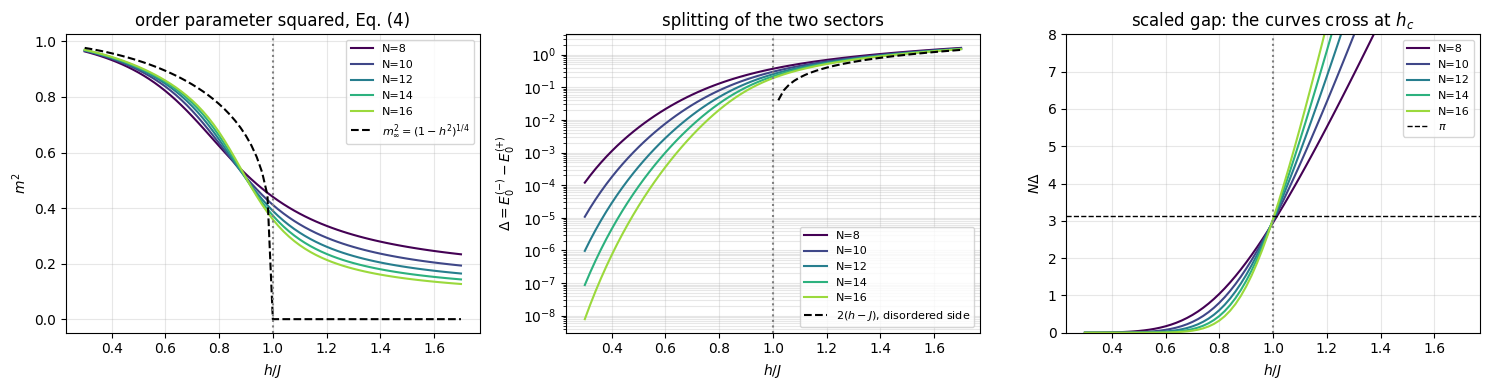

  N | m^2 at h=0.5 | m^2 at h=1.5 | gap at h=0.5 | gap at h=1.5 | N * gap at h=1 | S(N/2) at h=0.4
  8 |       0.8880 |       0.2604 |     5.86e-03 |       1.2315 |         2.9526 |          0.9999
 10 |       0.8969 |       0.2179 |     1.46e-03 |       1.1672 |         2.9892 |          1.0014
 12 |       0.9022 |       0.1872 |     3.66e-04 |       1.1266 |         3.0139 |          1.0017
 14 |       0.9059 |       0.1639 |     9.16e-05 |       1.0991 |         3.0318 |          1.0017
 16 |       0.9087 |       0.1458 |     2.29e-05 |       1.0797 |         3.0452 |          1.0017
exact: m^2(0.5) = 0.9306, m^2(1.5) = 0, Delta_inf(1.5) = 1.0000, N*Delta -> pi = 3.1416 at h_c, S -> 1 bit (cat state)


In [7]:
# ------------------------------------------------------------------------------
# FIGURE: order parameter, sector splitting, and the scaled gap
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
cols = plt.cm.viridis(np.linspace(0.0, 0.85, len(NS)))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(HS, scan[N]["m2"], "-", color=c, label=f"N={N}")
ax.plot(HS, tfim_exact_magnetisation(HS) ** 2, "k--", lw=1.5, label=r"$m_\infty^2=(1-h^2)^{1/4}$")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel("$m^2$"); ax.set_title("order parameter squared, Eq. (4)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
for N, c in zip(NS, cols):
    ax.semilogy(HS, scan[N]["gap"], "-", color=c, label=f"N={N}")
ax.semilogy(HS[HS > 1], 2 * (HS[HS > 1] - 1.0), "k--", lw=1.5, label=r"$2(h-J)$, disordered side")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\Delta=E_0^{(-)}-E_0^{(+)}$"); ax.set_title("splitting of the two sectors")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
ax = axes[2]
for N, c in zip(NS, cols):
    ax.plot(HS, N * scan[N]["gap"], "-", color=c, label=f"N={N}")
ax.axvline(1.0, color="gray", ls=":"); ax.axhline(np.pi, color="k", ls="--", lw=1, label=r"$\pi$")
ax.set_ylim(0, 8); ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$N\Delta$")
ax.set_title(r"scaled gap: the curves cross at $h_c$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

i_lo, i_hi, i_c = (int(np.argmin(abs(HS - x))) for x in (0.5, 1.5, 1.0))
print(f"{'N':>3} | {'m^2 at h=0.5':>12} | {'m^2 at h=1.5':>12} | {'gap at h=0.5':>12} | {'gap at h=1.5':>12} | {'N * gap at h=1':>14} | {'S(N/2) at h=0.4':>15}")
for N in NS:
    print(f"{N:>3} | {scan[N]['m2'][i_lo]:12.4f} | {scan[N]['m2'][i_hi]:12.4f} | {scan[N]['gap'][i_lo]:12.2e} | "
          f"{scan[N]['gap'][i_hi]:12.4f} | {N * scan[N]['gap'][i_c]:14.4f} | {scan[N]['S'][int(np.argmin(abs(HS - 0.4)))]:15.4f}")
print(f"exact: m^2(0.5) = {tfim_exact_magnetisation(0.5) ** 2:.4f}, m^2(1.5) = 0, Delta_inf(1.5) = {2 * 0.5:.4f}, "
      f"N*Delta -> pi = {np.pi:.4f} at h_c, S -> 1 bit (cat state)")

**Interpretation.**

- *Left*: $m^2$ is a smooth curve for every $N$. It does not jump; it does not vanish above $h_c$ (it decays as
  $1/N$ there, the value of an unordered state with $N$ independent spins); and below $h_c$ it sits **under** the
  exact $m_\infty^2$, because a finite chain cannot order completely. A transition is visible only as a steepening
  with $N$ - which is exactly what finite-size scaling will exploit in Sec. 8.
- *Centre* (logarithmic scale): the splitting of the two parity sectors behaves completely differently on the two
  sides. Above $h_c$ it converges to the bulk gap $2(h-J)$ and is finite. Below $h_c$ it collapses **exponentially
  with $N$** - at $h=0.5$ it falls from $6\times10^{-3}$ at $N=8$ to $2\times10^{-5}$ at $N=16$ - because there it is
  not an excitation energy at all but the **tunnelling splitting** between the two ferromagnets, the quantity
  computed in Chapter 7. The *physical* excitation gap $2(J-h)$ of the ordered phase lies above that doublet.
- *Right*: multiply the splitting by $N$. Below $h_c$ the exponential wins and $N\Delta\to0$; above $h_c$ the gap is
  finite and $N\Delta\to\infty$; exactly at $h_c$ the gap is $\propto1/N$ and $N\Delta$ is **independent of $N$** -
  this is the dynamical exponent $z=1$, and the constant is $\pi$. Curves for different $N$ therefore **cross** at
  the critical point, which is the cleanest locator in this notebook (Sec. 8).

## 6. Signature 3: entanglement entropy and the central charge

The entropy of a block is not an ordinary observable - no experiment measures it directly - but it is the sharpest
numerical signature of criticality, and it carries a number that identifies the *universality class*.

Away from the critical point the ground state of a gapped local Hamiltonian obeys an **area law**: in one dimension
the entropy of a block saturates at a constant of order $\ln\xi$, with $\xi$ the correlation length, independent of
the block size. That is the statement that made the matrix product states of the previous chapters work at all.

There is a trap on the ordered side. The parity-even ground state of a finite chain is not a ferromagnet; by
Eq. (3) it is the **cat state** $(\vert\!\uparrow\cdots\uparrow\rangle+\vert\!\downarrow\cdots\downarrow\rangle)/\sqrt2$, up to
corrections. Every cut of that state has exactly two Schmidt values $1/\sqrt2$, so it carries **exactly one bit**,
whatever $N$ and wherever the cut. Deep in the ordered phase the measured entropy is therefore $1.000$ bits for
every chain length - the table of Sec. 5 shows it - and that plateau is not criticality: it is the classical
correlation between two macroscopically distinct configurations. This is why the entropy is a poor *locator* of
this transition, its maximum sitting deep in the ordered phase rather than at $h_c$, while remaining an excellent
*identifier* of the critical theory, which is what the rest of this section does.

At the critical point $\xi$ diverges and the area law fails: the entropy grows with the size of the block,
logarithmically. For an **open** chain of $N$ sites cut after $\ell$ sites the precise form is (Calabrese and
Cardy 2004)

$$ S(\ell,N)=\frac{c}{6}\,\ln\Big[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\Big]+\text{const} , \qquad (8) $$

The only thing we do with this formula is **fit** it: plot the measured $S$ against the logarithm of the bracket
and read off the slope, which is $c/6$. What makes that worth doing is that $c$ comes out the same for *every*
model with the same kind of critical point - $1/2$ for the Ising transition, $1$ for the XX and XXZ critical line
of Sec. 10 - and different for different kinds. It is a fingerprint, and that is all we use it for.

> **What you need and what you do not.** The fitted number is called the **central charge**, and it comes from the
> field theory of critical points, which this course does not develop. Nothing here requires knowing where it
> comes from: compute the profile, fit the slope, compare the label with the known value. A finite chain does not
> possess a central charge; the fit returns an *effective* $c_{\rm eff}(N)$ that drifts towards $c$ as $N$ grows. The prefactor is $c/6$ for open boundaries and $c/3$ for periodic ones, the
familiar factor of two between one cut and two. Equation (8) turns a measured entropy profile into an
identification of the critical theory, and that is what the fit below does.

Two cautions come with it. The formula is asymptotic, so short blocks and small chains carry corrections; and in
the open Ising chain the corrections **alternate** with the parity of $\ell$, so the fitted $c$ depends visibly on
whether one fits all cuts or only the even ones.

In [8]:
# ==============================================================================
# STEP 4: entropy profile of a state, and the central charge fitted from Eq. (8)
# ==============================================================================
def entropy_profile(psi, N):
    """Entanglement entropy (bits) of every cut 1..N-1 of an N-spin state."""
    return np.array([float(entanglement_entropy(psi, range(l))) for l in range(1, N)])


def central_charge_fit(S_profile, N, skip=1, even_only=False):
    """Central charge from the Calabrese-Cardy law (8): linear fit of S against ln[(2N/pi) sin(pi l / N)].

    The slope is c/6 in BITS per unit of ln, i.e. c = 6 * slope * ln 2 in the natural (nats) normalisation used
    by conformal field theory.  `skip` drops the `skip` cuts nearest each end, where the asymptotic form is worst."""
    l = np.arange(1, N)
    x = np.log((2 * N / np.pi) * np.sin(np.pi * l / N))
    keep = np.ones_like(l, dtype=bool)
    keep[:skip] = keep[len(keep) - skip:] = False
    if even_only:
        keep &= (l % 2 == 0)
    slope, const = np.polyfit(x[keep], S_profile[keep], 1)
    return 6.0 * slope * np.log(2.0), const


# ------------------------------------------------------------------------------
# EXPERIMENT: the entropy profile at the critical point, and the central charge
# ------------------------------------------------------------------------------
i_crit = int(np.argmin(abs(HS - 1.0)))
prof = {N: entropy_profile(scan[N]["states"][i_crit], N) for N in NS}
prof_off = {N: entropy_profile(scan[N]["states"][int(np.argmin(abs(HS - 1.6)))], N) for N in NS}
print(f"{'N':>3} | {'c (all cuts)':>12} | {'c (even cuts)':>13} | {'S(N/2) at h=1':>13} | {'S(N/2) at h=1.6':>15}")
for N in NS:
    c_all, _ = central_charge_fit(prof[N], N)
    c_even, _ = central_charge_fit(prof[N], N, even_only=True)
    print(f"{N:>3} | {c_all:12.4f} | {c_even:13.4f} | {prof[N][N // 2 - 1]:13.4f} | {prof_off[N][N // 2 - 1]:15.4f}")
slope_N = np.polyfit(np.log(np.array(NS)), [prof[N][N // 2 - 1] for N in NS], 1)[0]
print(f"\nS(N/2) against ln N at h=1: slope = {slope_N:.4f} bits  ->  c = 6 * slope * ln2 = {6 * slope_N * np.log(2):.4f}   (exact 0.5)")
print(f"S(N/2) at h=1.6 grows by only {prof_off[16][7] - prof_off[8][3]:.3f} bits from N=8 to N=16 (area law: it saturates)")
assert 0.4 < 6 * slope_N * np.log(2) < 0.65

  N | c (all cuts) | c (even cuts) | S(N/2) at h=1 | S(N/2) at h=1.6
  8 |       0.5728 |        0.5718 |        0.5153 |          0.1941
 10 |       0.5687 |        0.5691 |        0.5469 |          0.1946
 12 |       0.5649 |        0.5662 |        0.5721 |          0.1948
 14 |       0.5616 |        0.5634 |        0.5930 |          0.1948
 16 |       0.5587 |        0.5608 |        0.6109 |          0.1948

S(N/2) against ln N at h=1: slope = 0.1379 bits  ->  c = 6 * slope * ln2 = 0.5734   (exact 0.5)
S(N/2) at h=1.6 grows by only 0.001 bits from N=8 to N=16 (area law: it saturates)


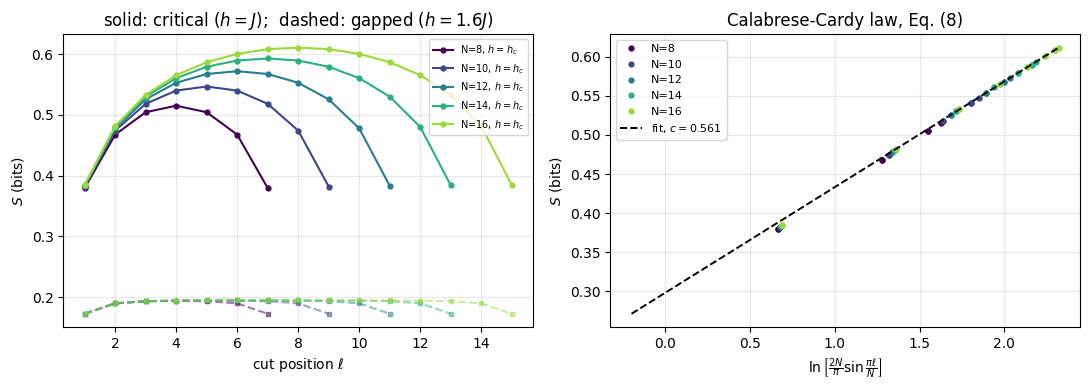

In [9]:
# ------------------------------------------------------------------------------
# FIGURE: entropy profiles and the Calabrese-Cardy fit
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(np.arange(1, N), prof[N], "o-", ms=3.5, color=c, label=f"N={N}, $h=h_c$")
    ax.plot(np.arange(1, N), prof_off[N], "s--", ms=3, color=c, alpha=0.5)
ax.set_xlabel("cut position $\\ell$"); ax.set_ylabel("$S$ (bits)")
ax.set_title("solid: critical ($h=J$);  dashed: gapped ($h=1.6J$)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[1]
for N, c in zip(NS, cols):
    l = np.arange(1, N)
    x = np.log((2 * N / np.pi) * np.sin(np.pi * l / N))
    ax.plot(x, prof[N], "o", ms=3.5, color=c, label=f"N={N}")
c_fit, const_fit = central_charge_fit(prof[16], 16, even_only=True)
xg = np.linspace(-0.2, np.log(2 * 16 / np.pi), 50)
ax.plot(xg, (c_fit / 6 / np.log(2)) * xg + const_fit, "k--", lw=1.4, label=rf"fit, $c={c_fit:.3f}$")
ax.set_xlabel(r"$\ln\left[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\right]$"); ax.set_ylabel("$S$ (bits)")
ax.set_title("Calabrese-Cardy law, Eq. (8)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** At the critical point the profile is a smooth arch that grows with $N$ and collapses onto a
straight line when plotted against the conformal coordinate of Eq. (8); its slope gives $c\approx0.5$, the Ising
value, from chains of at most sixteen spins. In the gapped phase the same profile is nearly flat and does not grow
with $N$ at all: the area law. The even-cut fit is the more accurate one, because the alternating corrections of
the open chain cancel from it.

> **Physics insight.** The central charge counts the massless degrees of freedom of the critical theory, and the
> entropy measures it without any knowledge of what the order parameter is. This is the modern route to
> identifying a critical point: not "which symmetry breaks", but "which conformal field theory describes it".

## 7. Signature 4: fidelity susceptibility - finding a transition without knowing the order parameter

All three signatures so far needed physical input: which operator orders, which symmetry sectors to use. The
fourth one needs none. Take the ground state at two nearby couplings and overlap them,

$$ F(h,\delta)=\big|\langle\psi_0(h)\vert\psi_0(h+\delta)\rangle\big| ,\qquad
   \chi_F(h)=\lim_{\delta\to0}\frac{2\big(1-F(h,\delta)\big)}{\delta^2} . \qquad (9) $$

The ground state changes slowly inside a phase and quickly where the state reorganises, so $\chi_F$ peaks at the
transition. Second-order perturbation theory makes this quantitative. With $H(h+\delta)=H(h)+\delta\,\partial_hH$
and $\partial_hH=-\sum_iX_i$ here,

$$ |\psi_0(h+\delta)\rangle=|\psi_0\rangle+\delta\sum_{n\neq0}\frac{\langle n|\partial_hH|\psi_0\rangle}{E_0-E_n}|n\rangle+\order(\delta^2)
   \quad\Longrightarrow\quad
   \chi_F=\sum_{n\neq0}\frac{\big|\langle n|\partial_hH|\psi_0\rangle\big|^2}{(E_n-E_0)^2} . \qquad (10) $$

The energy denominators explain everything: $\chi_F$ blows up where the gap closes, provided the perturbation
actually connects the ground state to the low-lying states. It is **extensive** inside a phase, so the quantity to
compare across sizes is $\chi_F/N$, and at a critical point it acquires the anomalous scaling
$\chi_F/N\sim N^{2/\nu-1}$, which for the Ising chain ($\nu=1$) means $\chi_F/N\propto N$.

In practice Eq. (9) is evaluated with a finite $\delta$ - here the spacing of the scan grid - which is why the
grid was chosen fine. No excited states and no operators are needed: two ground states and one inner product.

In [10]:
# ==============================================================================
# STEP 5: fidelity susceptibility from neighbouring ground states of the scan
# ==============================================================================
def fidelity_susceptibility(states, hs):
    """chi_F at the midpoints of the grid, Eq. (9), from the overlaps of neighbouring ground states.
    Returns (midpoint fields, chi_F).  The phase of each Lanczos eigenvector is arbitrary, hence the modulus."""
    f = np.array([abs(complex(jnp.vdot(states[i], states[i + 1]))) for i in range(len(states) - 1)])
    d = np.diff(hs)
    return 0.5 * (hs[1:] + hs[:-1]), 2.0 * (1.0 - f) / d ** 2


chi = {N: fidelity_susceptibility(scan[N]["states"], HS) for N in NS}

# CHECKPOINT 4: the finite-difference chi_F against the sum over states, Eq. (10), from a dense diagonalisation
N_F, H_F = 10, 1.1
w_f, V_f = np.linalg.eigh(np.asarray(dense_hamiltonian(tfim_terms(N_F, 1.0, H_F), N_F)))
dH = np.asarray(dense_hamiltonian(heisenberg_terms(N_F, 0.0, 0.0, 0.0, hx=-1.0), N_F))        # dH/dh = -sum_i X_i
v0 = V_f[:, 0]
num = V_f[:, 1:].T @ (dH @ v0)
chi_exact = float(np.sum(np.abs(num) ** 2 / (w_f[1:] - w_f[0]) ** 2))
mv_f = make_tfim_matvec(N_F)
psis = [sector_ground_state(lambda p, _h=float(hh): mv_f(p, _h), N_F, +1, m=50, restarts=2)[1]
        for hh in (H_F - 0.01, H_F + 0.01)]
chi_fd = float(2 * (1 - abs(complex(jnp.vdot(psis[0], psis[1])))) / 0.02 ** 2)
print(f"chi_F at N={N_F}, h={H_F}:  finite difference {chi_fd:.6f}   sum over states, Eq. (10) {chi_exact:.6f}   "
      f"(relative difference {abs(chi_fd - chi_exact) / chi_exact:.1e})")
assert abs(chi_fd - chi_exact) / chi_exact < 1e-3

chi_F at N=10, h=1.1:  finite difference 0.960457   sum over states, Eq. (10) 0.960261   (relative difference 2.0e-04)


## 8. Finite-size scaling: from five smooth curves to a critical point and two exponents

Every quantity computed so far is analytic in $h$; the transition shows up only in how the curves *change with*
$N$. Finite-size scaling turns that into numbers. Near a continuous transition the correlation length is the only
relevant length, $\xi\sim|h-h_c|^{-\nu}$, and on a chain of $N$ sites a quantity $A$ with bulk behaviour
$A\sim|h-h_c|^{\kappa}$ obeys

$$ A(h,N)=N^{-\kappa/\nu}\,f_A\big((h-h_c)\,N^{1/\nu}\big) , \qquad (11) $$

with $f_A$ a universal function. Three consequences are used below.

1. **Pseudo-critical points.** Any feature (the peak of $\chi_F$, the peak of $S$, the minimum of the gap) sits at
   a size-dependent $h^*(N)=h_c+a\,N^{-1/\nu}$. Extrapolating $h^*(N)$ against $N^{-1/\nu}$ gives $h_c$ - and with
   $\nu=1$ that is a straight line in $1/N$.
2. **Peak heights.** $\chi_F^{\max}/N\sim N^{2/\nu-1}$, so a log-log plot of the peak height measures $\nu$
   without any knowledge of $h_c$.
3. **Data collapse.** Plotting $m^2N^{2\beta/\nu}$ against $(h-h_c)N^{1/\nu}$ must put all chain lengths on one
   curve if $h_c$, $\beta$ and $\nu$ are right. This is the most demanding test, because it uses the whole curve
   rather than one feature, and it is the one that fails visibly when the exponents are wrong.

In [11]:
# ==============================================================================
# STEP 6: peak location by parabolic interpolation, and the scaling analysis
# ==============================================================================
def peak_position(x, y):
    """Position of the maximum of y(x) by a parabola through the largest point and its two neighbours
    (a three-point fit removes most of the grid discretisation)."""
    k = int(np.argmax(y))
    if k == 0 or k == len(y) - 1:
        return float(x[k])
    a, b, c = y[k - 1], y[k], y[k + 1]
    dx = x[k + 1] - x[k]
    return float(x[k] + 0.5 * dx * (a - c) / (a - 2 * b + c))


def crossing(N1, N2, lo=0.8, hi=1.4, J=1.0):
    """Field where N1 Delta(N1,h) = N2 Delta(N2,h), by bisection on the exact open-chain gap of Sec. 2."""
    f = lambda h: N1 * tfim_exact_gap(N1, J, h) - N2 * tfim_exact_gap(N2, J, h)
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if f(mid) * f(lo) > 0 else (lo, mid)
    return 0.5 * (lo + hi)


h_star_chi = np.array([peak_position(*chi[N]) for N in NS])
chi_max = np.array([np.max(chi[N][1]) for N in NS])
inv_N = 1.0 / np.array(NS, dtype=float)
pairs = [(8, 10), (10, 12), (12, 14), (14, 16), (16, 24), (24, 32), (32, 48), (48, 64), (64, 96)]
h_cross = np.array([crossing(a, b) for a, b in pairs])
x_cross = np.array([2.0 / (a + b) for a, b in pairs])

slope_hc, hc_fit = np.polyfit(inv_N, h_star_chi, 1)
hc_cross = np.polyfit(x_cross[-4:], h_cross[-4:], 1)[1]
expo, _ = np.polyfit(np.log(NS), np.log(chi_max / np.array(NS)), 1)
local_expo = np.diff(np.log(chi_max / np.array(NS))) / np.diff(np.log(NS))
print(f"{'N':>3} | {'h* (chi_F peak)':>15} | {'chi_F^max / N':>13} | {'N x gap at h=1':>14}")
for i, N in enumerate(NS):
    print(f"{N:>3} | {h_star_chi[i]:15.4f} | {chi_max[i] / N:13.3f} | {N * scan[N]['gap'][i_c]:14.4f}")
print("\ncrossings of N*Delta:  " + ", ".join(f"({a},{b}) {h:.4f}" for (a, b), h in zip(pairs, h_cross)))
print(f"extrapolated from the four largest pairs : h_c = {hc_cross:.5f}   (exact 1)")
print(f"extrapolated chi_F peak, h* = h_c + a/N  : h_c = {hc_fit:.4f}   (exact 1)")
print(f"peak height chi_F^max/N ~ N^{expo:.3f} over N=8..16  ->  nu = 2/(exponent+1) = {2 / (expo + 1):.3f}   (exact 1)")
print("  successive-size exponents: " + ", ".join(f"{e:.2f}" for e in local_expo) + "   (still drifting upwards)")
assert abs(hc_cross - 1.0) < 0.01 and abs(hc_fit - 1.0) < 0.05

  N | h* (chi_F peak) | chi_F^max / N | N x gap at h=1
  8 |          0.7189 |         0.314 |         2.9526
 10 |          0.7790 |         0.353 |         2.9892
 12 |          0.8189 |         0.395 |         3.0139
 14 |          0.8470 |         0.440 |         3.0318
 16 |          0.8678 |         0.485 |         3.0452

crossings of N*Delta:  (8,10) 0.9854, (10,12) 0.9902, (12,14) 0.9929, (14,16) 0.9947, (16,24) 0.9969, (24,32) 0.9984, (32,48) 0.9992, (48,64) 0.9996, (64,96) 0.9998
extrapolated from the four largest pairs : h_c = 1.00063   (exact 1)
extrapolated chi_F peak, h* = h_c + a/N  : h_c = 1.0172   (exact 1)
peak height chi_F^max/N ~ N^0.629 over N=8..16  ->  nu = 2/(exponent+1) = 1.228   (exact 1)
  successive-size exponents: 0.52, 0.62, 0.70, 0.73   (still drifting upwards)


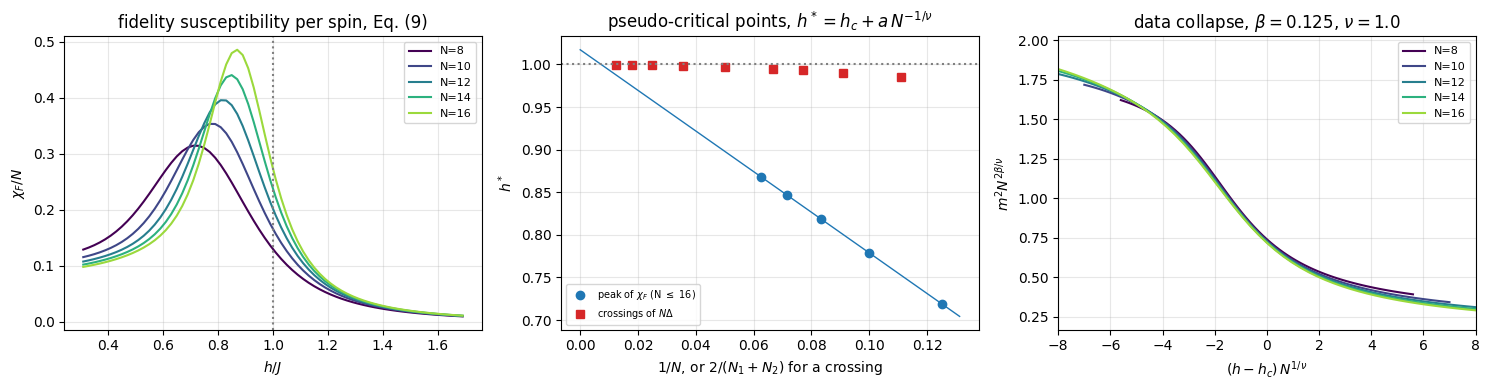

In [12]:
# ------------------------------------------------------------------------------
# FIGURE: fidelity susceptibility, extrapolation of the pseudo-critical points, and the data collapse
# ------------------------------------------------------------------------------
BETA, NU = 0.125, 1.0
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(chi[N][0], chi[N][1] / N, "-", color=c, label=f"N={N}")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\chi_F/N$"); ax.set_title("fidelity susceptibility per spin, Eq. (9)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(inv_N, h_star_chi, "o", color="C0", label=r"peak of $\chi_F$ (N $\leq$ 16)")
xg = np.linspace(0, 1.05 * inv_N.max(), 20)
ax.plot(xg, hc_fit + slope_hc * xg, "-", color="C0", lw=1)
ax.plot(x_cross, h_cross, "s", color="C3", label=r"crossings of $N\Delta$")
ax.axhline(1.0, color="gray", ls=":")
ax.set_xlabel(r"$1/N$, or $2/(N_1+N_2)$ for a crossing"); ax.set_ylabel("$h^*$")
ax.set_title(r"pseudo-critical points, $h^*=h_c+a\,N^{-1/\nu}$"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[2]
for N, c in zip(NS, cols):
    ax.plot((HS - 1.0) * N ** (1 / NU), scan[N]["m2"] * N ** (2 * BETA / NU), "-", color=c, label=f"N={N}")
ax.set_xlim(-8, 8)
ax.set_xlabel(r"$(h-h_c)\,N^{1/\nu}$"); ax.set_ylabel(r"$m^2N^{2\beta/\nu}$")
ax.set_title(rf"data collapse, $\beta={BETA}$, $\nu={NU}$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.**

- *Left*: $\chi_F/N$ has a peak that grows with $N$ and drifts towards $h_c$ **from below**. No order parameter,
  no symmetry sector and no excited state were used to produce it - only ground states and one inner product.
- *Centre*: both locators extrapolate to the exact $h_c=1$, but not equally well. The crossings of the scaled gap
  are at $0.985$ for the smallest pair and already at $0.9998$ for $(64,96)$, extrapolating to $1.0006$; a crossing
  cancels the leading finite-size correction that a single-size feature still carries. The $\chi_F$ peaks, which
  here use only $N\le16$, extrapolate to within two per cent.
- *Right*: with the exact exponents the five $m^2$ curves collapse onto one. The collapse is worst at the edges,
  where the small chains feel the boundaries, and best in the scaling window $|h-h_c|N\lesssim4$.

> **Numerical practice.** Not every scaling law is equally usable at small sizes. The crossing of $N\Delta$ gives
> $h_c$ to $10^{-3}$; the peak *positions* give it to a per cent; the peak *height* exponent, which should be
> $2/\nu-1=1$, comes out at $0.63$ over $N=8\ldots16$ and only drifts upwards as the chains grow - the printed
> successive-size exponents show that drift directly. The reason is in the left panel: at these sizes the peak
> still sits near $h^*\approx0.87$, outside the scaling window, so its height is not yet governed by the critical
> exponent. Quote an exponent only once the local exponents have stopped moving.

## 9. Beyond exact diagonalisation: the same analysis with DMRG

Sixteen spins were enough to see every signature and to get $h_c$ to a per cent, but the scaling analysis rested
on five points, the smallest of which is arguably too small to be in the scaling regime at all. Chapter 8 built a
method that removes that restriction: **DMRG** finds the ground state of a chain of a hundred spins directly in
the matrix product format. Since the critical ground state is the *worst* case for an MPS - the entropy of Sec. 6
grows with $\ln N$ instead of saturating - this is also an honest test of the method: the bond dimension needed
grows as $\chi\sim N^{c/6\cdot\text{something}}$, slowly, but it does grow.

> **Common pitfall.** The starting state matters more here than for a gapped antiferromagnet. A product state in
> the $Z$ basis has bond dimension one *and* positive energy for this ferromagnetic model, which leaves the first
> local eigenvalue problems almost no room: with a Néel start at $N=24$ the sweep stalls at $E=0$ instead of
> converging. Starting from $|+\cdots+\rangle$ converges to the exact energy at every size tried here. Whatever
> the start, check the converged energy against something independent - below, the exact free-fermion value.

The Hamiltonian enters as the matrix product operator of Chapter 8, which already covers the TFIM:
`xxz_mpo(N, 0, 0, -J, hx=-h)` builds $-J\sum Z_iZ_{i+1}-h\sum X_i$ as a $D=5$ machine (three of whose states are
never used here - a $D=3$ machine suffices, Exercise 6). The measurements are the MPS routines of the same
chapter: `mps_entropies` for every cut at once, and `mps_correlator` for $\langle Z_iZ_j\rangle$.

### 9.1 The order parameter at large $N$

Summing $\langle Z_iZ_j\rangle$ over all pairs, as in Eq. (4), costs $\order(N^2)$ correlators. The standard
substitute uses the *long-distance* value of the correlation function from a reference site in the bulk,

$$ m^2_{\rm bulk}(N)=\big\langle Z_{N/4}\,Z_{3N/4}\big\rangle , \qquad (12) $$

which has the same scaling with $N$ and costs $\order(N)$ contractions. Below the transition it tends to
$m_\infty^2$; above it, it decays exponentially; at $h_c$ it decays as a power, $\langle Z_0Z_r\rangle\sim r^{-1/4}$,
which is the exponent $\eta=1/4$ of the Ising universality class.

In [13]:
# ==============================================================================
# STEP 7: the TFIM as a matrix product operator, and its ground state by DMRG
# ==============================================================================
def tfim_mpo(N, J=1.0, h=1.0):
    """MPO of H = -J sum Z_i Z_{i+1} - h sum X_i, from the XXZ machine of Chapter 8 with Jxx = Jyy = 0."""
    return xxz_mpo(N, 0.0, 0.0, -J, hx=-h)


def dmrg_ground_state(N, h, chi=32, n_sweeps=5, J=1.0):
    """DMRG ground state of the TFIM, started from |+...+>, the ground state of the field term alone.

    WHY THAT START  a product state in the Z basis (all up, or Neel) is an eigenstate of every Z_i Z_{i+1} term, so
    the first local problems see a state of bond dimension one whose energy is POSITIVE for this ferromagnetic
    model.  That leaves the sweep very little room: with a Neel start at N = 24 it stalls at E = 0 instead of
    converging.  |+...+> is not an eigenstate of the ordering operator, costs nothing extra, and is the sensible
    physical guess, being exact as h -> infinity.
    RETURNS  (energy, B, lam, largest discarded weight of the last sweep)."""
    M0, _ = product_mps("+" * N, chi)
    B, lam, hist = dmrg(tfim_mpo(N, J, h), M0, chi, n_sweeps)
    eps = max(x[4] for x in hist if x[0] == n_sweeps - 1)
    return hist[-1][3], B, lam, eps


# ------------------------------------------------------------------------------
# CHECKPOINT 6: DMRG against exact diagonalisation (N=16) and against the exact energy at N=64
# ------------------------------------------------------------------------------
for h_ in (0.6, 1.0, 1.4):
    E_dmrg, B_16, lam_16, eps_16 = dmrg_ground_state(16, h_, chi=32, n_sweeps=5)
    i_h = int(np.argmin(abs(HS - h_)))
    E_ed = scan[16]["E0"][i_h]
    S_dmrg = float(mps_entropies(lam_16)[8])
    print(f"N=16, h={h_}:  E_DMRG = {E_dmrg:.10f} vs E_Lanczos = {E_ed:.10f} (difference {abs(E_dmrg - E_ed):.1e}), "
          f"S(N/2) = {S_dmrg:.6f} vs {scan[16]['S'][i_h]:.6f}, discarded weight {eps_16:.1e}")
    assert abs(E_dmrg - E_ed) < 1e-8 and abs(S_dmrg - scan[16]["S"][i_h]) < 1e-6

# the free-fermion formula is exact for ANY N: use it at N=64, where no state vector exists
for chi_ in (16, 32, 64):
    E64, _, _, eps64 = dmrg_ground_state(64, 1.0, chi=chi_, n_sweeps=5)
    E_exact_64 = -np.sum(np.linalg.svd(1.0 * np.eye(64) + 1.0 * np.eye(64, k=1), compute_uv=False))
    print(f"N=64 critical, chi={chi_:2d}: E = {E64:.10f}, exact {E_exact_64:.10f}, relative error "
          f"{abs(E64 - E_exact_64) / abs(E_exact_64):.1e}, discarded weight {eps64:.1e}")
assert abs(E64 - E_exact_64) / abs(E_exact_64) < 1e-8

N=16, h=0.6:  E_DMRG = -16.6654564171 vs E_Lanczos = -16.6654564171 (difference 1.8e-14), S(N/2) = 1.008346 vs 1.008346, discarded weight 3.4e-24


N=16, h=1.0:  E_DMRG = -20.0163879005 vs E_Lanczos = -20.0163879005 (difference 5.7e-14), S(N/2) = 0.610851 vs 0.610851, discarded weight 2.9e-22


N=16, h=1.4:  E_DMRG = -25.1622034887 vs E_Lanczos = -25.1622034887 (difference 1.7e-13), S(N/2) = 0.255292 vs 0.255292, discarded weight 6.6e-26


N=64 critical, chi=16: E = -81.1259800987, exact -81.1259801231, relative error 3.0e-10, discarded weight 1.4e-10


N=64 critical, chi=32: E = -81.1259801231, exact -81.1259801231, relative error 2.9e-14, discarded weight 1.8e-14


N=64 critical, chi=64: E = -81.1259801231, exact -81.1259801231, relative error 2.3e-15, discarded weight 1.7e-19


DMRG reproduces the Lanczos energies and entropies at $N=16$, and at $N=64$ - where the state vector would need
$10^{19}$ complex numbers - it reproduces the exact free-fermion energy, which for the open chain is
$E_0=-\sum_n s_n$ with $s_n$ the singular values of the bidiagonal matrix of Sec. 2. The error falls with $\chi$
and tracks the discarded weight, exactly as Chapter 8 described. *At the critical point* the convergence is
slower than in a gapped phase - that is the price of the logarithmic entropy.

### 9.2 The scan at $N=24$ and $N=48$

Now the same field scan as in Sec. 4, but with chains that are no longer reachable by exact diagonalisation. The
grid is coarse, because each point is a full DMRG run: about 1270 local eigenvalue problems for five sweeps at
$N=128$, roughly two minutes on one core. Three lengths, each twice the previous one, are what the scaling
arguments below need: a factor of two in $N$ is the unit in which $N^{-2\beta/\nu}$ and $\tfrac c6\log_2N$ are read.

In [14]:
# ==============================================================================
# EXPERIMENT: DMRG scan of the transition for three large chains
# ==============================================================================
NS_D = (32, 64, 128)                                       # each length is twice the previous one
HS_D = np.round(np.arange(0.70, 1.3001, 0.10), 4)          # coarse: every point is a full DMRG run
CHI_D = 48
dscan = {}
for N in NS_D:
    t0 = time.perf_counter()
    m2b, Sc, eps_all = [], [], []
    for h in HS_D:
        E, B, lam, eps = dmrg_ground_state(N, float(h), chi=CHI_D, n_sweeps=5)
        m2b.append(float(mps_correlator(B, lam, Z, N // 4, Z, 3 * N // 4)))
        Sc.append(float(mps_entropies(lam)[N // 2]))
        eps_all.append(eps)
        if abs(h - 1.0) < 1e-9:                                 # keep the critical state: Sec. 9.3 then needs no new run
            crit = {"E_c": E, "prof": np.asarray(mps_entropies(lam))[1:N],
                    "corr": np.array([float(mps_correlator(B, lam, Z, N // 2 - r // 2, Z, N // 2 + r // 2))
                                      for r in range(2, N // 2 + 1, 2)])}
    dscan[N] = {"m2": np.array(m2b), "S": np.array(Sc), "eps": np.array(eps_all), **crit}
    print(f"N={N:3d}: {len(HS_D)} fields in {time.perf_counter() - t0:5.1f} s | largest discarded weight {max(eps_all):.1e} | "
          f"S(N/2) at h=1: {dscan[N]['S'][int(np.argmin(abs(HS_D - 1.0)))]:.4f} bits")

N= 32: 7 fields in 200.5 s | largest discarded weight 4.6e-12 | S(N/2) at h=1: 0.7007 bits


N= 64: 7 fields in 414.6 s | largest discarded weight 1.2e-11 | S(N/2) at h=1: 0.7875 bits


N=128: 7 fields in 865.5 s | largest discarded weight 5.2e-15 | S(N/2) at h=1: 0.8725 bits


N=128 critical: central charge from Eq. (8) = 0.5140   (exact 0.5)
N=128 critical: local exponent of <Z Z> at the shortest distances = 0.264  (exact eta = 1/4);
   it drifts upwards with r: 0.26, 0.28, 0.29, 0.31, 0.32, 0.33  -- the open chain is not a pure power law


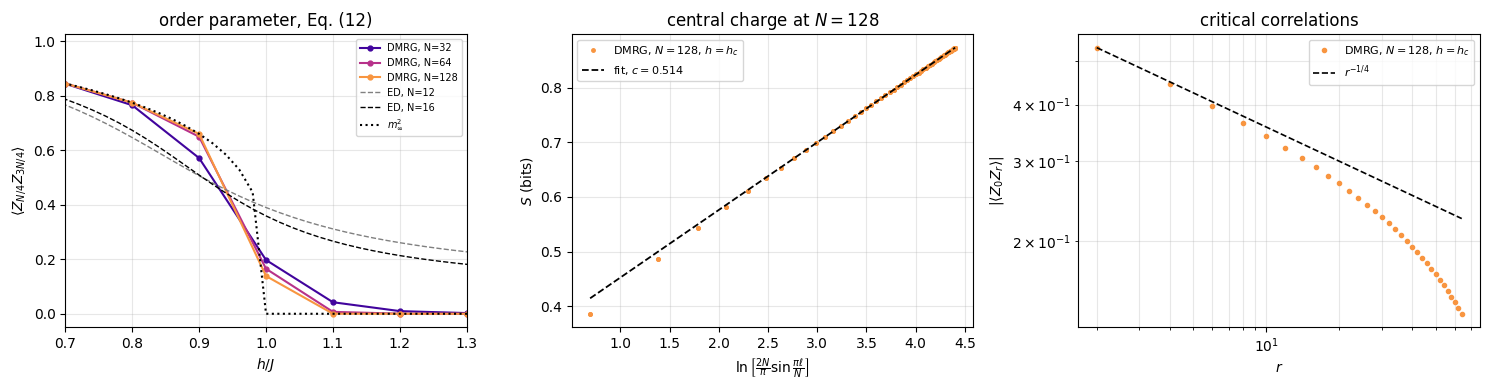

In [15]:
# ------------------------------------------------------------------------------
# FIGURE: DMRG scan, the critical entropy profile at the largest N, and the correlation function at h_c
# ------------------------------------------------------------------------------
N_C2 = NS_D[-1]                                                 # the largest chain of the scan, already solved at h_c
prof_c = dscan[N_C2]["prof"]
c_cft, const_c = central_charge_fit(prof_c, N_C2, skip=4, even_only=True)
rs_sym = np.arange(2, N_C2 // 2 + 1, 2)                         # centre-symmetric pairs: both sites far from the ends
corr_sym = dscan[N_C2]["corr"]
loc_eta = -np.diff(np.log(np.abs(corr_sym))) / np.diff(np.log(rs_sym))
eta_fit = loc_eta[0]
print(f"N={N_C2} critical: central charge from Eq. (8) = {c_cft:.4f}   (exact 0.5)")
print(f"N={N_C2} critical: local exponent of <Z Z> at the shortest distances = {eta_fit:.3f}  (exact eta = 1/4);")
print(f"   it drifts upwards with r: " + ", ".join(f"{e:.2f}" for e in loc_eta[:6]) + "  -- the open chain is not a pure power law")
assert abs(c_cft - 0.5) < 0.05 and abs(eta_fit - 0.25) < 0.05      # the SHORT-distance exponent is the critical one

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
cols_d = plt.cm.plasma(np.linspace(0.1, 0.75, len(NS_D)))
ax = axes[0]
for N, c in zip(NS_D, cols_d):
    ax.plot(HS_D, dscan[N]["m2"], "o-", ms=3.5, color=c, label=f"DMRG, N={N}")
for N, c in zip((12, 16), ("gray", "black")):
    ax.plot(HS, scan[N]["m2"], "--", lw=1, color=c, label=f"ED, N={N}")
ax.plot(HS, tfim_exact_magnetisation(HS) ** 2, "k:", lw=1.5, label=r"$m_\infty^2$")
ax.set_xlim(0.7, 1.3); ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\langle Z_{N/4}Z_{3N/4}\rangle$")
ax.set_title("order parameter, Eq. (12)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[1]
l = np.arange(1, N_C2)
x_c = np.log((2 * N_C2 / np.pi) * np.sin(np.pi * l / N_C2))
ax.plot(x_c, prof_c, "o", ms=2.5, color=cols_d[-1], label=rf"DMRG, $N={N_C2}$, $h=h_c$")
xg = np.linspace(x_c.min(), x_c.max(), 20)
ax.plot(xg, (c_cft / 6 / np.log(2)) * xg + const_c, "k--", lw=1.3, label=rf"fit, $c={c_cft:.3f}$")
ax.set_xlabel(r"$\ln\left[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\right]$"); ax.set_ylabel("$S$ (bits)")
ax.set_title(rf"central charge at $N={N_C2}$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
ax.loglog(rs_sym, np.abs(corr_sym), "o", ms=3, color=cols_d[-1], label=rf"DMRG, $N={N_C2}$, $h=h_c$")
ax.loglog(rs_sym, np.abs(corr_sym)[0] * (rs_sym / rs_sym[0]) ** -0.25, "k--", lw=1.2, label=r"$r^{-1/4}$")
ax.set_xlabel("$r$"); ax.set_ylabel(r"$|\langle Z_0Z_r\rangle|$")
ax.set_title("critical correlations"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.** The DMRG curves continue the exact-diagonalisation ones smoothly and steepen further: at
$N=128$ the order parameter is close to a step function, which is what the transition looks like as $N$ grows. The
two quantities that were only *approximately* right at sixteen spins are now sharp: the central charge comes out
at $c\approx0.50$ instead of $0.5\pm0.05$, and the critical correlations follow $r^{-1/4}$ over a decade, giving
the exponent $\eta=1/4$ that no chain of sixteen spins can show.

> **Numerical practice.** Every DMRG run here is monitored by its discarded weight, and the critical point is the
> hardest case: the same $\chi$ that is ample in a gapped phase is merely adequate at $h_c$. When a scaling
> analysis is the goal, converge $\chi$ *at the critical point* and use that value everywhere.

## 10. A transition the same procedure cannot pin down

Everything so far worked because the Ising transition is a textbook continuous transition: a power-law divergent
correlation length, clean exponents, features that drift as $N^{-1/\nu}$. Not every transition is like that. The
XXZ chain

$$ H=\sum_i\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\big) \qquad (13) $$

is **critical for the whole range** $-1<\Delta\le1$ - a gapless line, not a point, with central charge $c=1$ - and
gapped with Néel order for $\Delta>1$. The transition at $\Delta=1$ is of the **Kosterlitz-Thouless** type: the
gap does not open as a power of $\Delta-1$ but as

$$ \Delta_{\rm gap}\sim\exp\Big(-\frac{\pi^2}{\sqrt{2(\Delta-1)}}\Big) , \qquad (14) $$

an essential singularity. At $\Delta=1.1$ that gap is smaller than $10^{-9}$, which no finite chain can resolve;
the correlation length is astronomically larger than any $N$ we can reach, so every chain in the neighbourhood of
$\Delta=1$ *looks* critical. Finite-size scaling does not fail loudly here - it fails quietly, by giving a smooth
curve with no feature to extrapolate.

The experiment below measures the same central charge as in Sec. 6, now as a function of $\Delta$, and asks where
the transition is. First a checkpoint: at $\Delta=0$ the model is the XX chain, free fermions again, so its exact
entropy profile is available for any $N$ and grades the DMRG result.

In [16]:
# ==============================================================================
# STEP 8: the XXZ chain -- free-fermion check at Delta = 0, then the central charge against Delta
# ==============================================================================
def xx_ground_entropy_profile(N, J=1.0):
    """Exact entanglement entropy (bits) of every cut of the XX-chain ground state at half filling.

    MATH  hopping matrix h1[i,i+1] = h1[i+1,i] = 2J;  occupy the N/2 lowest single-particle levels;
          C = sum_occ phi phi^T;  S(l) = -sum_m [nu log2 nu + (1-nu) log2(1-nu)], nu = eig(C[:l,:l])  (Peschel 2003).
    This is the ground-state twin of the time-dependent reference used in Chapter 9."""
    h1 = 2.0 * J * (np.eye(N, k=1) + np.eye(N, k=-1))
    _, V = np.linalg.eigh(h1)
    C = V[:, : N // 2] @ V[:, : N // 2].T
    out = []
    for l in range(1, N):
        nu = np.clip(np.linalg.eigvalsh(C[:l, :l]), 1e-15, 1 - 1e-15)
        out.append(float(-np.sum(nu * np.log2(nu) + (1 - nu) * np.log2(1 - nu))))
    return np.array(out)


N_Z, CHI_Z = 32, 32
B_xx, lam_xx, _ = dmrg(xxz_mpo(N_Z, 1.0, 1.0, 0.0), product_mps(("01" * N_Z)[:N_Z], CHI_Z)[0], CHI_Z, 5)
prof_dmrg = np.asarray(mps_entropies(lam_xx))[1:N_Z]
prof_exact = xx_ground_entropy_profile(N_Z)
print(f"XX chain at N={N_Z}: max |S_DMRG - S_free-fermion| = {np.max(np.abs(prof_dmrg - prof_exact)):.1e}")
print(f"  central charge: DMRG {central_charge_fit(prof_dmrg, N_Z, skip=3, even_only=True)[0]:.4f}, "
      f"free fermions {central_charge_fit(prof_exact, N_Z, skip=3, even_only=True)[0]:.4f}   (exact 1)")
assert np.max(np.abs(prof_dmrg - prof_exact)) < 1e-4

XX chain at N=32: max |S_DMRG - S_free-fermion| = 1.7e-05
  central charge: DMRG 1.1174, free fermions 1.1175   (exact 1)


Delta = 0.00:  c_eff =  1.117 | S(N/2) = 1.2217 bits | staggered <Z Z> at r=N/2 = +0.0000 | E = -40.032775


Delta = 0.50:  c_eff =  1.118 | S(N/2) = 1.0972 bits | staggered <Z Z> at r=N/2 = +0.0073 | E = -47.323707


Delta = 1.00:  c_eff =  1.069 | S(N/2) = 1.0409 bits | staggered <Z Z> at r=N/2 = +0.0367 | E = -55.989261


Delta = 1.05:  c_eff =  1.071 | S(N/2) = 1.0416 bits | staggered <Z Z> at r=N/2 = +0.0429 | E = -56.929100


Delta = 1.50:  c_eff =  1.218 | S(N/2) = 1.1267 bits | staggered <Z Z> at r=N/2 = +0.1627 | E = -66.002399


Delta = 2.00:  c_eff =  1.330 | S(N/2) = 1.2832 bits | staggered <Z Z> at r=N/2 = +0.4550 | E = -77.441211
(6 DMRG runs at N=32, chi=32 in 133 s)


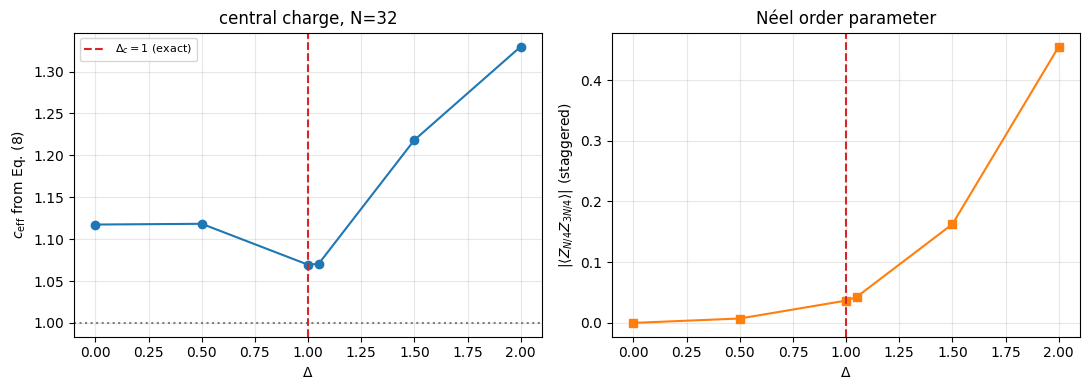

In [17]:
# ==============================================================================
# EXPERIMENT: central charge and staggered correlations across the Kosterlitz-Thouless point
# ==============================================================================
DELTAS = (0.0, 0.5, 1.0, 1.05, 1.5, 2.0)
kt = {}
t0 = time.perf_counter()
for D in DELTAS:
    B_d, lam_d, hist_d = dmrg(xxz_mpo(N_Z, 1.0, 1.0, D), product_mps(("01" * N_Z)[:N_Z], CHI_Z)[0], CHI_Z, 5)
    prof_d = np.asarray(mps_entropies(lam_d))[1:N_Z]
    c_eff, _ = central_charge_fit(prof_d, N_Z, skip=3, even_only=True)
    cst = (-1) ** (N_Z // 2) * float(mps_correlator(B_d, lam_d, Z, N_Z // 4, Z, 3 * N_Z // 4))
    kt[D] = {"c": c_eff, "S_mid": prof_d[N_Z // 2 - 1], "cst": cst, "E": hist_d[-1][3]}
    print(f"Delta = {D:4.2f}:  c_eff = {c_eff:6.3f} | S(N/2) = {prof_d[N_Z // 2 - 1]:.4f} bits | "
          f"staggered <Z Z> at r=N/2 = {cst:+.4f} | E = {hist_d[-1][3]:.6f}")
print(f"({len(DELTAS)} DMRG runs at N={N_Z}, chi={CHI_Z} in {time.perf_counter() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
ax.plot(DELTAS, [kt[D]["c"] for D in DELTAS], "o-", color="C0")
ax.axhline(1.0, color="gray", ls=":"); ax.axvline(1.0, color="C3", ls="--", label=r"$\Delta_c=1$ (exact)")
ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$c_{\rm eff}$ from Eq. (8)")
ax.set_title(f"central charge, N={N_Z}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(DELTAS, [abs(kt[D]["cst"]) for D in DELTAS], "s-", color="C1")
ax.axvline(1.0, color="C3", ls="--")
ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$|\langle Z_{N/4}Z_{3N/4}\rangle|$ (staggered)")
ax.set_title("Néel order parameter"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** The critical phase is identified correctly: $c_{\rm eff}\approx1$ for every $\Delta\le1$, the
free-boson value, distinct from the $c=1/2$ of the Ising chain. Above $\Delta=1$ the estimate falls - but it falls
*smoothly*, and at $\Delta=1.05$ it is still close to one. There is no peak to locate, no crossing, nothing to
extrapolate: on this data alone one could place the transition anywhere between $\Delta\approx1$ and
$\Delta\approx1.4$. The staggered correlator tells the same story from the other side.

The reason is Eq. (14). Just above $\Delta=1$ the correlation length is enormous - at $\Delta=1.05$ it exceeds
$10^{6}$ sites - so a chain of 48, or 480, or 48 000 spins is still *inside* the correlation length and looks
critical. The finite-size scaling of Sec. 8 assumed $\xi\sim|g-g_c|^{-\nu}$, a power law; an essential singularity
breaks that assumption, and the honest conclusion from these runs is "the transition is somewhere near
$\Delta\approx1$, and this method cannot do better". Locating a KT point needs either the dedicated logarithmic
corrections known for this class, or a completely different observable (the spin stiffness, or level spectroscopy
of excited states).

> **Caution.** A scaling analysis that produces a number always produces a number. The question is whether the
> model satisfies the assumption behind the analysis. The Ising and XXZ cases in this notebook are the same code
> and the same procedure, applied to a transition that fits the assumption and to one that does not.

## 11. Cost, and what limits the analysis

* **Exact diagonalisation** gives *everything* - all four signatures, exact gaps, arbitrary observables - for
  $N\le18$ or so, at $\order(2^N)$ memory. The scan of Sec. 4 was 71 fields $\times$ 5 lengths $\times$ 2 sectors
  $=710$ ground states, a couple of minutes on one core. Symmetry sectors are what make excited states cheap.
* **DMRG** reaches $N=100$ and more at $\order(N\chi^3)$ per sweep, but only for ground states, only for
  quantities expressible through the MPS, and with a bond dimension that must be converged *at the critical
  point*, where the entropy grows logarithmically. It bought the sharp $c=1/2$, the exponent $\eta=1/4$ and the
  large-$N$ end of the scaling analysis.
* **Free fermions** are not a method but a *grader*: whenever the model happens to be quadratic, $\order(N^3)$
  linear algebra gives the exact answer for any $N$ and checks everything else. Use them wherever they exist, and
  do not mistake them for a general tool.
* **What limits the result** is not the eigensolver - the gaps agreed with the exact formula to $10^{-7}$ - but
  the *range of $N$*. Exponents come from how quantities change with $N$, so the accuracy of $\nu$ is set by the
  ratio of the largest to the smallest chain and by how far the smallest one is from the scaling regime.
  Corrections to scaling, which this notebook ignored, are the next term to model when higher accuracy is needed.

## 12. Key takeaways

* A quantum phase transition is a property of the **thermodynamic limit**; every finite chain is analytic, gapped
  and symmetric. The numerical task is to extract the limit from a sequence of finite systems.
* The order parameter of a finite chain vanishes identically by symmetry, Eq. (3). Use $m^2$, or a long-distance
  correlator, and never a single $\langle Z_j\rangle$.
* A symmetry turns a ground-state solver into an excited-state solver: Lanczos inside a parity sector gives the
  gap as a difference of two ground-state energies.
* Four independent signatures locate the same transition: the order parameter, the gap ($\Delta\propto1/N$ at
  criticality, $z=1$), the entanglement entropy (area law off criticality, $S=\frac{c}{6}\ln[\cdots]$ at it), and
  the fidelity susceptibility, which needs no order parameter and no symmetry - only two ground states and an
  overlap.
* The **central charge** read from the entropy identifies the critical theory: $c=1/2$ for the Ising chain,
  $c=1$ for the XX/XXZ critical line.
* **Finite-size scaling** converts drifting features into $h_c$ and the exponents: pseudo-critical points
  extrapolate as $N^{-1/\nu}$, peak heights scale with known powers, and a data collapse tests everything at once.
* DMRG extends the same analysis to a hundred spins, which is what makes $c$ and $\eta$ accurate; at a critical
  point the bond dimension must be converged, because the entropy no longer saturates.
* The procedure has an assumption - a power-law correlation length - and a Kosterlitz-Thouless transition
  violates it. Then the analysis returns a smooth curve and no transition point, and saying so is the correct
  scientific answer.

## 13. Exercises

1. ★ **The gap exponent.** From the scan of Sec. 4, fit $\Delta(N,h_c)$ against $1/N$ and confirm $z=1$. Then fit
   $\Delta(N\to\infty,h)$ against $|h-h_c|$ away from the critical point and recover $z\nu=1$.
2. ★ **Two locators.** Compare the crossings of $N\Delta$ with the peaks of $\chi_F$ at the same sizes. Which
   converges faster, and by what power of $N$? Then add a third: the peak of $\partial m^2/\partial h$.
3. ★★ **The correlation exponent from small chains.** At $h=h_c$ compute $\langle Z_0Z_r\rangle$ for $N=16$ by exact
   diagonalisation and fit $\eta$. Compare with the $N=128$ DMRG value $\eta\approx1/4$ and explain the difference.
4. ★★ **Unknown exponents.** Pretend $\beta$ and $\nu$ are unknown. Define a collapse cost - for instance the
   spread of the rescaled curves after interpolation onto a common grid - and minimise it over $(h_c,\beta,\nu)$
   with a coarse grid search. How close do you get to $(1,1/8,1)$, and which exponent is determined worst?
5. ★★ **A three-parameter phase diagram.** Add a longitudinal field, $-h_z\sum_iZ_i$, which breaks the parity
   symmetry explicitly. Show that the transition disappears: the gap no longer closes and $\chi_F$ no longer
   diverges. Map $\chi_F^{\max}(h_z)$ and find where the line of transitions ends.
6. ★★ **A smaller machine.** The TFIM MPO used here is the $D=5$ XXZ machine with three unused states. Write the
   $D=3$ Ising machine explicitly, check it with `mpo_to_dense` at $N=6$, and confirm that DMRG gives the same
   energy at $N=64$ with a cheaper contraction.
7. ★★★ **Convergence at a critical point.** Repeat the $N=128$ critical run at $\chi=16,32,48,64$ and plot the
   error of the energy and of the fitted central charge against the discarded weight. How large must $\chi$ be for
   $c$ to be right to one per cent, and how does that requirement grow with $N$?
8. ★★★ **The other side of the KT point.** At $\Delta=1.5$ and $\Delta=2$ extract the correlation length from the
   exponential decay of $\langle Z_0Z_r\rangle-m_{\rm st}^2$ and compare with Eq. (14). How far above $\Delta=1$ do you
   have to go before $\xi$ fits inside a chain of 128 spins?

## 14. References

* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970). — the exact
  solution used as the grader of this notebook.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011). — the standard text;
  scaling, exponents, the TFIM as the canonical example.
* M. E. Fisher and M. N. Barber, *Scaling theory for finite-size effects in the critical region*,
  Phys. Rev. Lett. **28**, 1516 (1972). — finite-size scaling.
* P. Calabrese and J. Cardy, *Entanglement entropy and quantum field theory*, J. Stat. Mech. P06002 (2004). —
  Eq. (8) and the central charge from entanglement.
* G. Vidal, J. I. Latorre, E. Rico and A. Kitaev, *Entanglement in quantum critical phenomena*,
  Phys. Rev. Lett. **90**, 227902 (2003). — the logarithmic growth of entanglement at criticality.
* P. Zanardi and N. Paunković, *Ground state overlap and quantum phase transitions*, Phys. Rev. E **74**, 031123
  (2006); W.-L. You, Y.-W. Li and S.-J. Gu, Phys. Rev. E **76**, 022101 (2007). — fidelity and fidelity
  susceptibility as universal detectors.
* I. Peschel, *Calculation of reduced density matrices from correlation functions*, J. Phys. A **36**, L205
  (2003). — the free-fermion entropy used as a check.
* J. M. Kosterlitz and D. J. Thouless, *Ordering, metastability and phase transitions in two-dimensional systems*,
  J. Phys. C **6**, 1181 (1973); A. W. Sandvik, *Computational studies of quantum spin systems*, AIP Conf. Proc.
  **1297**, 135 (2010). — the KT transition and why it resists finite-size scaling.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/